# ORBIT Pipeline

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo = cwd.parent if cwd.name == "notebooks" else cwd
if repo.name == "tcda_uq":
    sys.path.insert(0, str(repo.parent))
elif (repo / "tcda_uq").exists():
    sys.path.insert(0, str(repo))

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

This example runs the actual ORBIT point-cloud to persistence to
silhouette pipeline, then treats the generated counterfactual
silhouettes as potential topological outcomes for a small TATE band.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

from tcda_uq import evaluate_coverage, tate_band
from tcda_uq.datasets import make_orbit_causal
from tcda_uq.estimators import cross_fit

In [3]:
rng = np.random.default_rng(20)
orbit = make_orbit_causal(
    n=24,
    p_reverse=0.25,
    interval=(0.0, 0.25),
    resolution=22,
    homology_dims=(0, 1),
    num_pts=40,
    rng=21,
)
po = orbit["potential_outcomes"]
n = po.shape[0]
X = rng.normal(size=(n, 3))
A = np.array([0, 1] * (n // 2))
rng.shuffle(A)
phi = po[np.arange(n), A]
sample = (phi, A, X)

In [4]:
fit = cross_fit(
    sample,
    orbit["tseq"],
    n_basis=4,
    n_splits=2,
    random_state=22,
    propensity_estimator=LogisticRegression(max_iter=500),
)
band = tate_band(fit, method="mbb", d=1, alpha=0.10, n_boot=80, rng=23)
truth = orbit["true_effect"][1]
pd.DataFrame(
    [
        {
            "dataset": "ORBIT synthetic point clouds",
            "homology_dim": 1,
            "coverage_against_sample_truth": evaluate_coverage(band, truth).coverage,
            "mean_width": band.mean_width(),
        }
    ]
)

,dataset,homology_dim,coverage_against_sample_truth,mean_width
0,ORBIT synthetic point clouds,1,1.0,0.046254


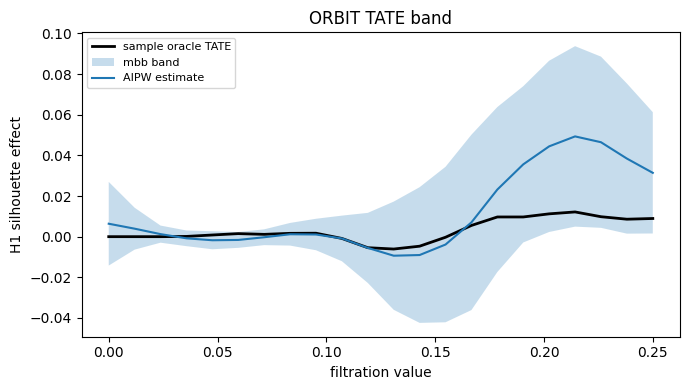

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(orbit["tseq"], truth, color="black", lw=2, label="sample oracle TATE")
ax.fill_between(orbit["tseq"], band.lower, band.upper, alpha=0.25, label="mbb band")
ax.plot(orbit["tseq"], band.center, lw=1.5, label="AIPW estimate")
ax.set(xlabel="filtration value", ylabel="H1 silhouette effect", title="ORBIT TATE band")
ax.legend(loc="best", fontsize=8)
fig.tight_layout()